In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Multiple Linear Regression

### Data Collection

In [46]:
auto=pd.read_csv(r'datasets/auto.csv')

In [47]:
auto.head(10)

,symboling,normalized losses,make,fuel type,aspiration,doors,style,wheels,engine location,wheel base,...,engine size,fuel system,bore,stroke,compression ratio,horsepower,peak rpm,city mpg,highway mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.4,7.0,160,5500,16,22,?


### EDA & Pre-Processing

In [48]:
auto.columns

Index(['symboling', 'normalized losses', 'make', 'fuel type', 'aspiration',
       'doors', 'style', 'wheels', 'engine location', 'wheel base', 'length',
       'width', 'height', 'curb weight', 'engine type', 'cylinders',
       'engine size', 'fuel system', 'bore', 'stroke', 'compression ratio',
       'horsepower', 'peak rpm', 'city mpg', 'highway mpg', 'price'],
      dtype='object')

In [49]:
auto.drop(columns=['symboling','normalized losses'])

,make,fuel type,aspiration,doors,style,wheels,engine location,wheel base,length,width,...,engine size,fuel system,bore,stroke,compression ratio,horsepower,peak rpm,city mpg,highway mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [50]:
auto['fuel type'].unique()
auto['aspiration'].unique()
auto['doors'].unique()

array(['two', 'four', '?'], dtype=object)

In [51]:
#programming rules
#1.longer detailed variable names >> shorter names
#2.comments are part of part of the code not optional
#3.Function to do exactly one thing.

auto.replace('?', 0,inplace=True) #replacing the values in the df
#auto.drop(['normalized losses'], axis=1,inplace=True) #drop a col in the df ; 0 - row index, 1 - col index ; inplace=True - modifying the original df

df_car_new = auto.copy(deep=True) #creating a copy of the df


#encoding cols with two category variable to binary

df_car_new['fuel type'] = df_car_new['fuel type'].map({'gas':1, 'diesel':0}) #encoding fuel type to binary
df_car_new['aspiration']=df_car_new['aspiration'].map({'std':1,'turbo':0})
df_car_new['doors']=df_car_new['doors'].map({'four':1,'two':0})

In [52]:
df_car_new['doors'].replace("?",np.nan,inplace=True)

C:\Users\nikhi\AppData\Local\Temp\ipykernel_21316\506340231.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_car_new['doors'].replace("?",np.nan,inplace=True)


In [53]:
df_car_new.head(15)

,symboling,normalized losses,make,fuel type,aspiration,doors,style,wheels,engine location,wheel base,...,engine size,fuel system,bore,stroke,compression ratio,horsepower,peak rpm,city mpg,highway mpg,price
0,3,0,alfa-romero,1,1,0.0,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,0,alfa-romero,1,1,0.0,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,0,alfa-romero,1,1,0.0,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,1,1,1.0,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,1,1,1.0,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
5,2,0,audi,1,1,0.0,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
6,1,158,audi,1,1,1.0,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
7,1,0,audi,1,1,1.0,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,18920
8,1,158,audi,1,0,1.0,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
9,0,0,audi,1,0,0.0,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.4,7.0,160,5500,16,22,0


In [54]:
def getDummies(df, category_cols):
    for col in category_cols:
        dummy_df = pd.get_dummies(df[col], drop_first=True, dtype='int')
        new_col_map = {c: f"{col}_{c}" for c in dummy_df.columns}
        dummy_df.rename(columns=new_col_map,inplace=True)
        df = pd.concat([df,dummy_df],axis=1)
    df.drop(category_cols,axis=1,inplace=True)
    return df

In [55]:
encode_cols = ['make', 'fuel system', 'cylinders', 'engine type', 'symboling', 'wheels', 'style'] #cat cols stored insida a list
df_car_1 = getDummies(df=df_car_new, category_cols=encode_cols) #return the df with numerical cols

df_car_1['price'] = df_car_new['price'].copy(deep=True)
df_car_1['engine location'] = df_car_1['engine location'].map({'front':1, 'rear':0})


# loop which casts the col dtype to float

for col in df_car_1.select_dtypes('object').columns:
    df_car_1[col] = df_car_1[col].astype(float)

In [56]:
df_car_1

,normalized losses,fuel type,aspiration,doors,engine location,wheel base,length,width,height,curb weight,...,symboling_0,symboling_1,symboling_2,symboling_3,wheels_fwd,wheels_rwd,style_hardtop,style_hatchback,style_sedan,style_wagon
0,0.0,1,1,0.0,1,88.6,168.8,64.1,48.8,2548,...,0,0,0,1,0,1,0,0,0,0
1,0.0,1,1,0.0,1,88.6,168.8,64.1,48.8,2548,...,0,0,0,1,0,1,0,0,0,0
2,0.0,1,1,0.0,1,94.5,171.2,65.5,52.4,2823,...,0,1,0,0,0,1,0,1,0,0
3,164.0,1,1,1.0,1,99.8,176.6,66.2,54.3,2337,...,0,0,1,0,1,0,0,0,1,0
4,164.0,1,1,1.0,1,99.4,176.6,66.4,54.3,2824,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,95.0,1,1,1.0,1,109.1,188.8,68.9,55.5,2952,...,0,0,0,0,0,1,0,0,1,0
201,95.0,1,0,1.0,1,109.1,188.8,68.8,55.5,3049,...,0,0,0,0,0,1,0,0,1,0
202,95.0,1,1,1.0,1,109.1,188.8,68.9,55.5,3012,...,0,0,0,0,0,1,0,0,1,0
203,95.0,0,0,1.0,1,109.1,188.8,68.9,55.5,3217,...,0,0,0,0,0,1,0,0,1,0


In [57]:
df_car_1.columns

Index(['normalized losses', 'fuel type', 'aspiration', 'doors',
       'engine location', 'wheel base', 'length', 'width', 'height',
       'curb weight', 'engine size', 'bore', 'stroke', 'compression ratio',
       'horsepower', 'peak rpm', 'city mpg', 'highway mpg', 'price',
       'make_audi', 'make_bmw', 'make_chevrolet', 'make_dodge', 'make_honda',
       'make_isuzu', 'make_jaguar', 'make_mazda', 'make_mercedes-benz',
       'make_mercury', 'make_mitsubishi', 'make_nissan', 'make_peugot',
       'make_plymouth', 'make_porsche', 'make_renault', 'make_saab',
       'make_subaru', 'make_toyota', 'make_volkswagen', 'make_volvo',
       'fuel system_2bbl', 'fuel system_4bbl', 'fuel system_idi',
       'fuel system_mfi', 'fuel system_mpfi', 'fuel system_spdi',
       'fuel system_spfi', 'cylinders_five', 'cylinders_four', 'cylinders_six',
       'cylinders_three', 'cylinders_twelve', 'cylinders_two',
       'engine type_dohcv', 'engine type_l', 'engine type_ohc',
       'engine type_oh

In [58]:
num_vars = [
       'wheel base',
       'length', 'width', 'height', 'curb weight', 
       'engine size', 'bore',
       'stroke', 'compression ratio', 
       'horsepower', 'peak rpm', 'city mpg',
       'highway mpg', 'price'
       ]

In [59]:

df_car_1[num_vars]

,wheel base,length,width,height,curb weight,engine size,bore,stroke,compression ratio,horsepower,peak rpm,city mpg,highway mpg,price
0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


<Figure size 1600x1600 with 0 Axes>

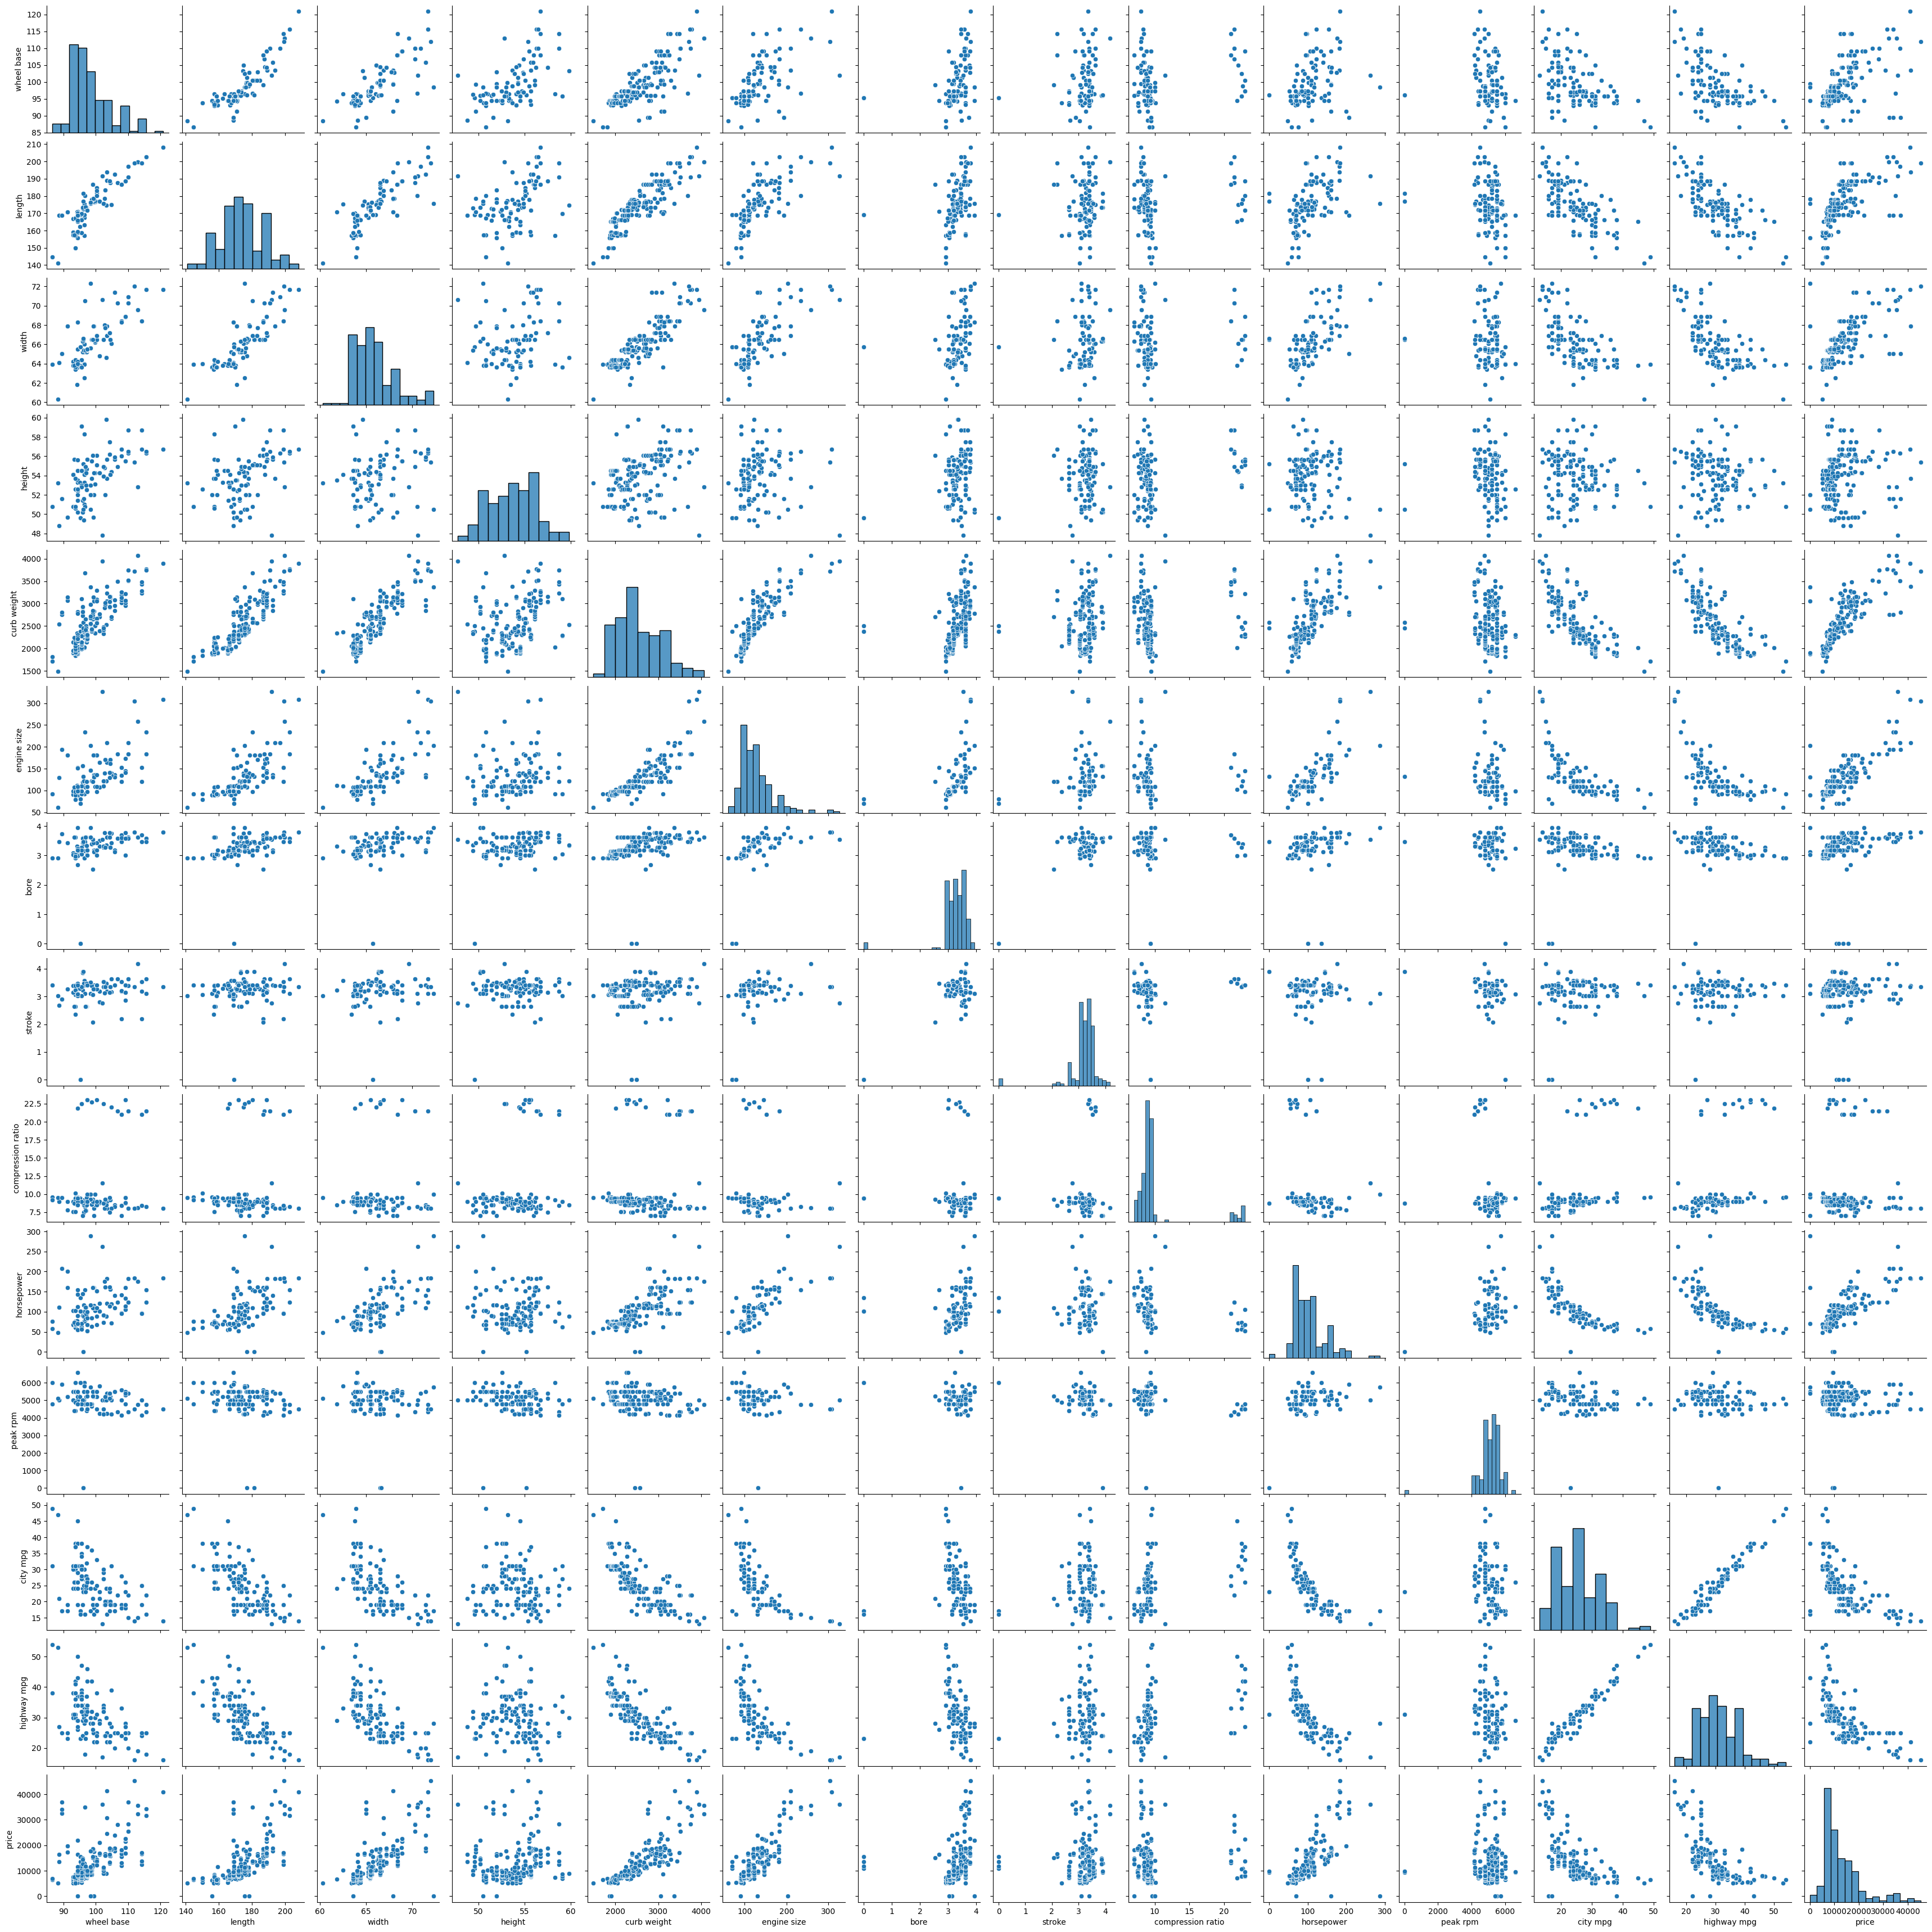

In [60]:
plt.figure(figsize=(16,16))
sns.pairplot(df_car_1[num_vars]) #pairplot for bi-variate analysis
plt.show()

In [61]:
df_car_1.columns

Index(['normalized losses', 'fuel type', 'aspiration', 'doors',
       'engine location', 'wheel base', 'length', 'width', 'height',
       'curb weight', 'engine size', 'bore', 'stroke', 'compression ratio',
       'horsepower', 'peak rpm', 'city mpg', 'highway mpg', 'price',
       'make_audi', 'make_bmw', 'make_chevrolet', 'make_dodge', 'make_honda',
       'make_isuzu', 'make_jaguar', 'make_mazda', 'make_mercedes-benz',
       'make_mercury', 'make_mitsubishi', 'make_nissan', 'make_peugot',
       'make_plymouth', 'make_porsche', 'make_renault', 'make_saab',
       'make_subaru', 'make_toyota', 'make_volkswagen', 'make_volvo',
       'fuel system_2bbl', 'fuel system_4bbl', 'fuel system_idi',
       'fuel system_mfi', 'fuel system_mpfi', 'fuel system_spdi',
       'fuel system_spfi', 'cylinders_five', 'cylinders_four', 'cylinders_six',
       'cylinders_three', 'cylinders_twelve', 'cylinders_two',
       'engine type_dohcv', 'engine type_l', 'engine type_ohc',
       'engine type_oh

In [62]:
df_car_1['price'].corr(df_car_1['highway mpg'])

np.float64(-0.6876750740856988)

In [63]:
#function to generate corelation matrix of the num cols

df_car_1.corr().head(50)

,normalized losses,fuel type,aspiration,doors,engine location,wheel base,length,width,height,curb weight,...,symboling_0,symboling_1,symboling_2,symboling_3,wheels_fwd,wheels_rwd,style_hardtop,style_hatchback,style_sedan,style_wagon
normalized losses,1.000000,0.089637,0.046293,-0.126151,0.204579,-0.196317,-0.236562,-0.196650,-0.167410,-0.261289,...,-0.198051,0.147162,0.120624,0.057511,0.079703,-0.066462,-0.051038,0.193389,0.048156,-0.244094
fuel type,0.089637,1.000000,0.401397,-0.181675,-0.040070,-0.308346,-0.212679,-0.233880,-0.284631,-0.217275,...,-0.156438,0.159302,0.005524,0.128056,0.090342,-0.122035,-0.018635,0.202093,-0.185623,-0.028183
aspiration,0.046293,0.401397,1.000000,-0.046350,-0.057191,-0.257611,-0.234539,-0.300567,-0.087311,-0.324902,...,0.029547,0.079080,0.131943,-0.117276,0.145681,-0.112470,0.029074,-0.009786,-0.017111,-0.018908
doors,-0.126151,-0.181675,-0.046350,1.000000,0.138613,0.445696,0.393593,0.202072,0.547651,0.195683,...,0.464914,-0.220685,-0.217149,-0.443285,0.034894,-0.075486,-0.229237,-0.612202,0.521878,0.331133
engine location,0.204579,-0.040070,-0.057191,0.138613,1.000000,0.187790,0.050989,0.051698,0.106234,-0.050468,...,0.084915,0.072877,0.052413,-0.312905,0.144799,-0.158772,-0.394978,0.087754,0.114369,0.045417
wheel base,-0.196317,-0.308346,-0.257611,0.445696,0.187790,1.000000,0.874587,0.795144,0.589435,0.776386,...,0.274072,-0.283085,-0.180357,-0.244038,-0.460355,0.498830,-0.008608,-0.386094,0.291086,0.210899
length,-0.236562,-0.212679,-0.234539,0.393593,0.050989,0.874587,1.000000,0.841118,0.491029,0.877728,...,0.248857,-0.360253,-0.171755,-0.028868,-0.508714,0.538370,0.047292,-0.436269,0.269647,0.219683
width,-0.196650,-0.233880,-0.300567,0.202072,0.051698,0.795144,0.841118,1.000000,0.279210,0.867032,...,0.106804,-0.240230,-0.163606,0.043742,-0.472116,0.511149,0.066360,-0.222308,0.154637,0.060639
height,-0.167410,-0.284631,-0.087311,0.547651,0.106234,0.589435,0.491029,0.279210,1.000000,0.295572,...,0.301354,-0.223722,-0.035818,-0.415848,-0.100273,0.039814,-0.072328,-0.477476,0.235863,0.459148
curb weight,-0.261289,-0.217275,-0.324902,0.195683,-0.050468,0.776386,0.877728,0.867032,0.295572,1.000000,...,0.205350,-0.377306,-0.183255,0.121437,-0.666039,0.669987,0.098956,-0.287501,0.099425,0.164075


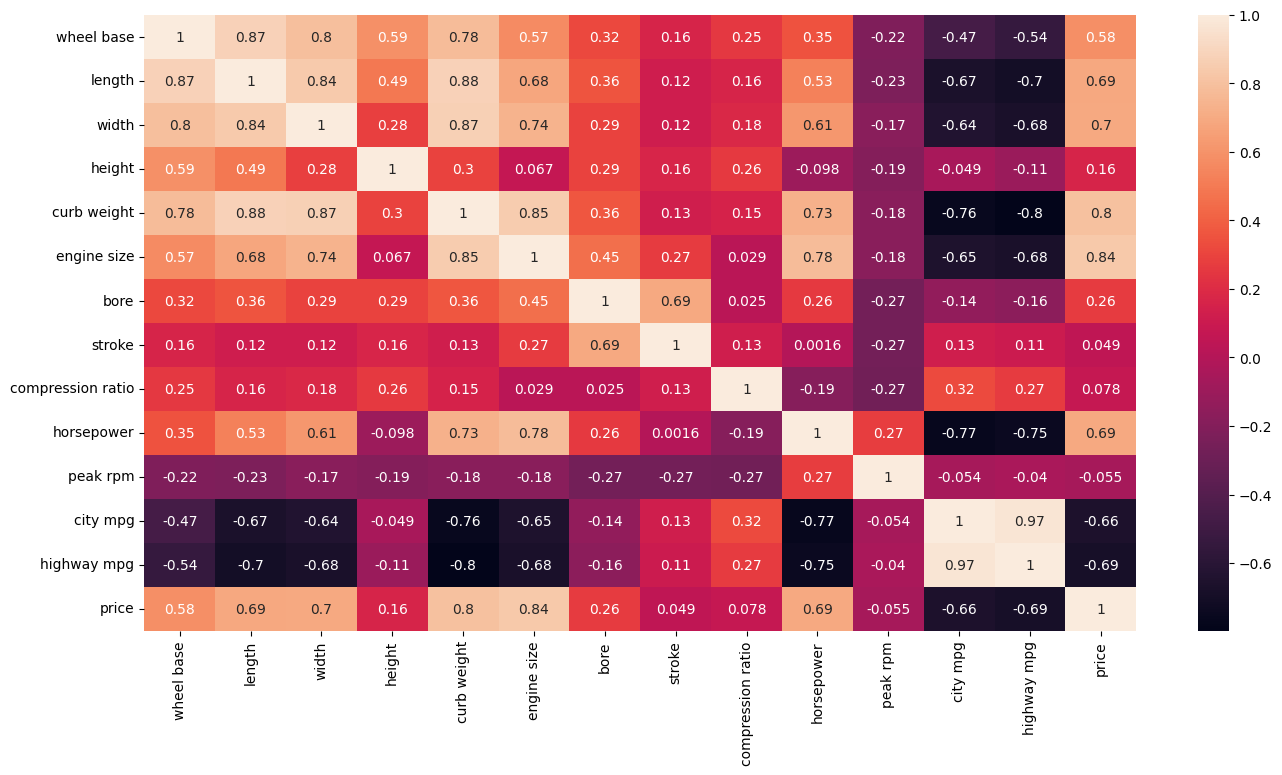

In [64]:
plt.figure(figsize=(16,8))
sns.heatmap(df_car_1[num_vars].corr(), annot=True)
plt.show()

In [65]:
#co-relations w.r.t price

corr_matrix = df_car_1.corr()['price']
corr_matrix = pd.DataFrame(corr_matrix).reset_index()
corr_matrix.sort_values(by='price', ascending=False).head(20) #function to sort values of a df

,index,price
18,price,1.000000
10,engine size,0.838097
9,curb weight,0.799773
7,width,0.695654
14,horsepower,0.691288
6,length,0.685019
65,wheels_rwd,0.623644
5,wheel base,0.578804
27,make_mercedes-benz,0.517527
44,fuel system_mpfi,0.488836


### Model Iteration-I

In [66]:
var_1 = corr_matrix.sort_values(by='price', ascending=False).head(20)['index'].unique() #selecting the top 10 variables

In [67]:
var_1

array(['price', 'engine size', 'curb weight', 'width', 'horsepower',
       'length', 'wheels_rwd', 'wheel base', 'make_mercedes-benz',
       'fuel system_mpfi', 'cylinders_six', 'engine type_ohcv',
       'make_bmw', 'make_jaguar', 'bore', 'make_porsche', 'style_hardtop',
       'cylinders_five', 'symboling_3', 'cylinders_twelve'], dtype=object)

In [68]:
df_car_itr_1 = df_car_1[var_1]

In [69]:
df_car_itr_1

,price,engine size,curb weight,width,horsepower,length,wheels_rwd,wheel base,make_mercedes-benz,fuel system_mpfi,cylinders_six,engine type_ohcv,make_bmw,make_jaguar,bore,make_porsche,style_hardtop,cylinders_five,symboling_3,cylinders_twelve
0,13495.0,130,2548,64.1,111.0,168.8,1,88.6,0,1,0,0,0,0,3.47,0,0,0,1,0
1,16500.0,130,2548,64.1,111.0,168.8,1,88.6,0,1,0,0,0,0,3.47,0,0,0,1,0
2,16500.0,152,2823,65.5,154.0,171.2,1,94.5,0,1,1,1,0,0,2.68,0,0,0,0,0
3,13950.0,109,2337,66.2,102.0,176.6,0,99.8,0,1,0,0,0,0,3.19,0,0,0,0,0
4,17450.0,136,2824,66.4,115.0,176.6,0,99.4,0,1,0,0,0,0,3.19,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,16845.0,141,2952,68.9,114.0,188.8,1,109.1,0,1,0,0,0,0,3.78,0,0,0,0,0
201,19045.0,141,3049,68.8,160.0,188.8,1,109.1,0,1,0,0,0,0,3.78,0,0,0,0,0
202,21485.0,173,3012,68.9,134.0,188.8,1,109.1,0,1,1,1,0,0,3.58,0,0,0,0,0
203,22470.0,145,3217,68.9,106.0,188.8,1,109.1,0,0,1,0,0,0,3.01,0,0,0,0,0


In [70]:
y = df_car_itr_1.pop('price') #Seperate the target from the df

In [71]:
df_car_itr_1

,engine size,curb weight,width,horsepower,length,wheels_rwd,wheel base,make_mercedes-benz,fuel system_mpfi,cylinders_six,engine type_ohcv,make_bmw,make_jaguar,bore,make_porsche,style_hardtop,cylinders_five,symboling_3,cylinders_twelve
0,130,2548,64.1,111.0,168.8,1,88.6,0,1,0,0,0,0,3.47,0,0,0,1,0
1,130,2548,64.1,111.0,168.8,1,88.6,0,1,0,0,0,0,3.47,0,0,0,1,0
2,152,2823,65.5,154.0,171.2,1,94.5,0,1,1,1,0,0,2.68,0,0,0,0,0
3,109,2337,66.2,102.0,176.6,0,99.8,0,1,0,0,0,0,3.19,0,0,0,0,0
4,136,2824,66.4,115.0,176.6,0,99.4,0,1,0,0,0,0,3.19,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,141,2952,68.9,114.0,188.8,1,109.1,0,1,0,0,0,0,3.78,0,0,0,0,0
201,141,3049,68.8,160.0,188.8,1,109.1,0,1,0,0,0,0,3.78,0,0,0,0,0
202,173,3012,68.9,134.0,188.8,1,109.1,0,1,1,1,0,0,3.58,0,0,0,0,0
203,145,3217,68.9,106.0,188.8,1,109.1,0,0,1,0,0,0,3.01,0,0,0,0,0


In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_car_itr_1, y)

In [73]:
y_train

55     10945.0
42     10345.0
11     16925.0
98      8249.0
151     6338.0
        ...   
136    18150.0
36      7295.0
179    15998.0
170    11199.0
32      5399.0
Name: price, Length: 153, dtype: float64

In [74]:
#Using statsmodels' module for regession 

import statsmodels.api as sm

x_train_sm_1 = sm.add_constant(X_train)
lr_1 = sm.OLS(y_train, x_train_sm_1)
lr_model_1 = lr_1.fit()
print(lr_model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     31.17
Date:                Sun, 28 Dec 2025   Prob (F-statistic):           8.90e-40
Time:                        16:26:07   Log-Likelihood:                -1454.7
No. Observations:                 153   AIC:                             2949.
Df Residuals:                     133   BIC:                             3010.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -2.007e+04   1.89

In [75]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def getVIF(df):

    vif = pd.DataFrame()
    vif['Features'] = df.columns
    vif['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by = "VIF", ascending = False)

    return vif

In [76]:
getVIF(X_train)

,Features,VIF
6,wheel base,2371.16
4,length,1918.27
2,width,1802.56
1,curb weight,367.79
0,engine size,168.54
13,bore,68.28
3,horsepower,32.49
5,wheels_rwd,4.26
8,fuel system_mpfi,3.64
10,engine type_ohcv,3.54


### Model Iteration-II

In [77]:
var_2 = ['price', 'engine size', 'horsepower',
        'wheels(rwd)','make(mercedes-benz)',
       'fuel system(mpfi)', 'cylinders(six)', 'engine type(ohcv)',
       'make(bmw)', 'make(jaguar)', 'bore', 'make(porsche)',
       'style(hardtop)', 'cylinders(five)', 'symboling(3)',
       'cylinders(twelve)']

In [78]:
df_car_1.columns

Index(['normalized losses', 'fuel type', 'aspiration', 'doors',
       'engine location', 'wheel base', 'length', 'width', 'height',
       'curb weight', 'engine size', 'bore', 'stroke', 'compression ratio',
       'horsepower', 'peak rpm', 'city mpg', 'highway mpg', 'price',
       'make_audi', 'make_bmw', 'make_chevrolet', 'make_dodge', 'make_honda',
       'make_isuzu', 'make_jaguar', 'make_mazda', 'make_mercedes-benz',
       'make_mercury', 'make_mitsubishi', 'make_nissan', 'make_peugot',
       'make_plymouth', 'make_porsche', 'make_renault', 'make_saab',
       'make_subaru', 'make_toyota', 'make_volkswagen', 'make_volvo',
       'fuel system_2bbl', 'fuel system_4bbl', 'fuel system_idi',
       'fuel system_mfi', 'fuel system_mpfi', 'fuel system_spdi',
       'fuel system_spfi', 'cylinders_five', 'cylinders_four', 'cylinders_six',
       'cylinders_three', 'cylinders_twelve', 'cylinders_two',
       'engine type_dohcv', 'engine type_l', 'engine type_ohc',
       'engine type_oh

In [ ]:

df_car_itr_2 = new_func()

y = df_car_itr_2.pop('price')

x_train, x_test, y_train, y_test = train_test_split(df_car_itr_2, y)

x_train_sm_2 = sm.add_constant(x_train)
lr_1 = sm.OLS(y_train, x_train_sm_2)
lr_model_2  = lr_1.fit()
print(lr_model_2.summary())

KeyError: "['price', 'wheels(rwd)', 'make(mercedes-benz)', 'fuel system(mpfi)', 'cylinders(six)', 'engine type(ohcv)', 'make(bmw)', 'make(jaguar)', 'make(porsche)', 'style(hardtop)', 'cylinders(five)', 'symboling(3)', 'cylinders(twelve)'] not in index"